# Test TcLab PID real time


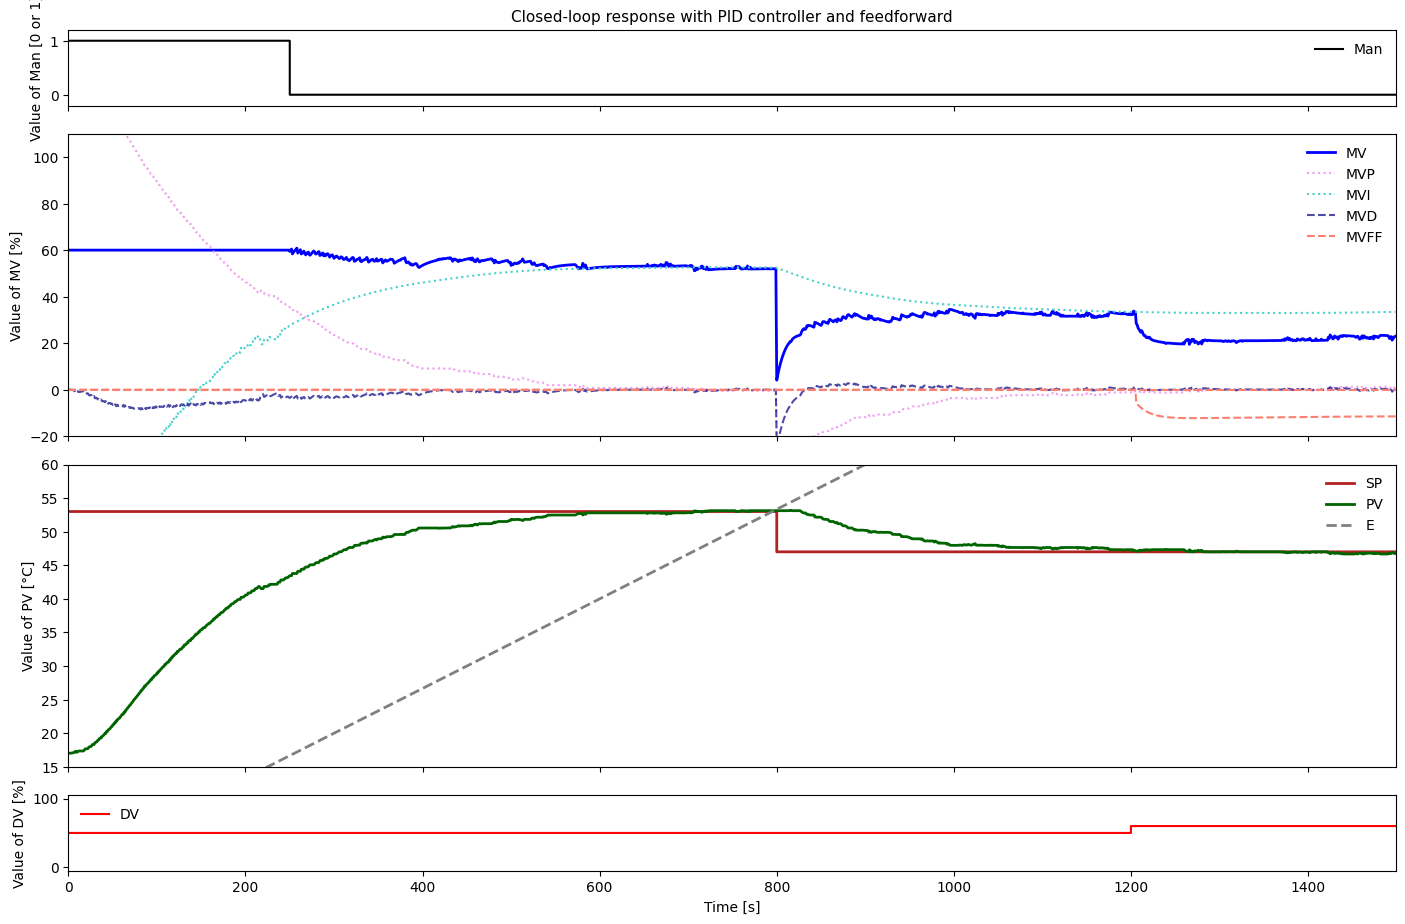

TCLab disconnected successfully.


<Figure size 640x480 with 0 Axes>

In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import tclab
from IPython.display import display, clear_output
from datetime import datetime

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode
import package_LAB
from package_LAB import LL_RT, PID_RT, IMC_tuning


Ts = 1.0
Tsim = 1500
t = np.arange(0, Tsim, Ts)

PV_0 = 48
DV_0 = 50
MV_0 = 50

senario = 1

if senario == 1:
    SPPath = {0: PV_0 + 5, 800: PV_0-1}
    ManPath = {0: True, 250: False}
    MVManPath = {0:MV_0+10}
    DVPatch = {0: DV_0, 1200: DV_0+10}
    FF = True
    ManFF = False
elif  senario == 2:
    SPPath = {0: PV_0, 300: PV_0 - 5}
    ManPath = {0: False}
    MVManPath = {0:MV_0+10}
    DVPatch = {0: DV_0, 600: DV_0+10}
    FF = True
    ManFF = False

# Modèles (issus de tes identifications)
K_p, T1_p, T2_p, theta_p = 0.32, 149.5, 15.0, 4.0   # Procédé (H1 -> T1)
K_d, T1_d, T2_d, theta_d = 0.36, 170.77, 6.12, 5.43  # Perturbation (H2 -> T1)

# Réglages PID
# DISCUTE ALPHA ET GAMMA
alpha = 0.8
Kc, Ti, Td = IMC_tuning(K_p, T1_p, T2_p, theta_p, 0.9)
# Kc = Kc*0.9
print("Kc",Kc, "Ti",Ti, "Td",Td)
MVMin, MVMax = 0, 100

t = []

E = []
EP = []
ED = []
PV = []
SP = []
DV = []
MV = []
MVP =[]
MVI =[]
MVD =[]
MVFF_Delay = []
MVFF_LL = []
MVFF = []
MVMan = []
Man = []



fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios':[1, 4, 4, 1]})
plt.tight_layout()
plt.subplots_adjust(hspace=0.15) # Réduit un peu l'espace entre les graphiques
plt.show()
# --- Graph 1 : État Manuel vs Auto (Man) ---
ax1_Man, = ax1.step([0,Tsim],[0,100], color='black', label='Man', where='post', linewidth=1.5)
ax1.set_ylabel('Value of Man [0 or 1]')
ax1.set_ylim([-0.2, 1.2])
ax1.set_yticks([0, 1])
ax1.legend(loc='upper right', frameon=False)
ax1.set_title(f"Closed-loop response with PID controller and feedforward", fontsize=11)



ax2_MV,   = ax2.plot([0,Tsim],[0,100], color='blue', label='MV', linewidth=2)
ax2_MVP,  = ax2.plot([0,Tsim],[0,100], color='violet', linestyle=':', label='MVP', alpha=0.8)
ax2_MVI,  = ax2.plot([0,Tsim],[0,100], color='mediumturquoise', linestyle=':', label='MVI')
ax2_MVD,  = ax2.plot([0,Tsim],[0,100], color='navy', linestyle='--', label='MVD', alpha=0.7)
ax2_MVFF, = ax2.plot([0,Tsim],[0,100], color='salmon', linestyle='--', label='MVFF')
ax2.axhline(0, color='salmon', linestyle='--', linewidth=1.5)
ax2.set_ylabel('Value of MV [%]')
ax2.set_ylim(-20, 110)
ax2.legend(loc='upper right', frameon=False)

ax3_SP, = ax3.step([0,Tsim],[0,100], color='firebrick', label='SP', where='post', linewidth=2)
ax3_PV, = ax3.plot([0,Tsim],[0,100], color='darkgreen', label='PV', linewidth=2)
ax3_E, = ax3.plot([0,Tsim],[0,100], color='grey', label='E', linewidth=2, linestyle='--')
ax3.set_ylabel('Value of PV [°C]')
ax3.legend(loc='upper right', frameon=False)
ax3.set_ylim(15, 60)

ax4_DV, = ax4.step([0,Tsim],[0,100], color='red', label='DV', where='post', linewidth=1.5)
ax4.set_ylabel('Value of DV [%]')
ax4.set_xlabel('Time [s]')
ax4.set_xlim([0, Tsim])
ax4.legend(loc='upper left', frameon=False)

lab = tclab.TCLab()

Exp = True

for i in range(Tsim):
    t.append(i)
    
    if t[-1] == 0:
        last_time = time.time()    

    PV.append(lab.T1)

    SelectPath_RT(SPPath, t, SP)
    SelectPath_RT(DVPatch, t, DV)

    Delay_RT(DV - DV_0*np.ones_like(DV), theta_d, Ts, MVFF_Delay, 0)
    #def LL_RT(MV,Kp,Tlag,Tlead,Ts,PV,PVInit=0,method='EBD'):
    LL_RT(MVFF_Delay, -K_d/K_p, T1_p, T1_d, Ts, MVFF_LL, 0)
    if FF:
        LL_RT(MVFF_LL, 1.0, T2_p, T2_d, Ts, MVFF, 0)
    else:
        MVFF.append(0)

    SelectPath_RT(MVManPath, t, MVMan)
    SelectPath_RT(ManPath, t, Man)

    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF, PV_0)
    
    lab.Q1(MV[-1])
    lab.Q2(DV[-1])

    now = time.time()
    delta = now - last_time
    
    time.sleep(np.max([0, Ts - delta]))
    last_time = time.time()

    E_copy = np.abs(np.array(E))+20
    ax1_Man.set_data(t, Man)
    ax2_MV.set_data(t, MV)
    ax2_MVP.set_data(t, MVP)
    ax2_MVI.set_data(t, MVI)
    ax2_MVD.set_data(t, MVD)
    ax2_MVFF.set_data(t, MVFF)
    ax3_SP.set_data(t, SP)
    ax3_PV.set_data(t, PV)
    #ax3_E.set_data(t, E_copy)
    ax4_DV.set_data(t, DV)

    
    clear_output(wait=True)
    display(fig)

    # Remove if increasing x-axis lenght is not desired
    ax1.set_xlim(0, t[-1]+1)
    ax2.set_xlim(0, t[-1]+1)
    ax3.set_xlim(0, t[-1]+1)
    ax4.set_xlim(0, t[-1]+1)


lab.close()

# Save Data
# ---------
now = datetime.now()
date_time = now.strftime("%Y-%m-%d-%Hh%M")
my_data = np.vstack((np.array(t), np.array(Man), np.array(MV), np.array(MVP),
                        np.array(MVI), np.array(MVD), np.array(MVFF),
                        np.array(SP), np.array(PV), np.array(DV)))
# np.array(E_copy), 

my_data = my_data.T
nameFile = 'Data/RT_test_on_' + date_time + '.txt'
if not os.path.exists('Data'):
    os.makedirs('Data')
np.savetxt(nameFile, my_data, delimiter=',',
            header='t,Man,MV,MVP,MVI,MVD,MVFF,SP,PV,DV', comments='')

# Save Plot
# ---------
if not os.path.exists('Plots'):
    os.makedirs('Plots')
titleName = 'RT_test_on_' + date_time
plt.savefig('Plots/' + titleName + '.png', transparent=True)
plt.savefig('Plots/' + titleName + '.pdf', transparent=True)


